In [90]:
import os
while 'src' not in os.listdir():
    os.chdir("..")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import networkx as nx

from src.reading_in import read_in_proteins, is_essential_protein
from src.community_finding import partition_graph, size_distribution_of_communities, eliminate_small_communities, get_adjacent_communities

Read in

In [91]:
G = read_in_proteins(connected=True, include_essential_proteins=False)

compute communitites, we expect communities to be about the size of complexes (~20)

Average size of communitites: 13.95774647887324
Meduan size of communitites: 12.5


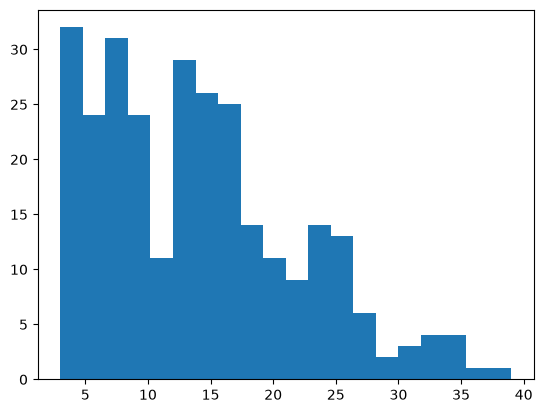

20
39


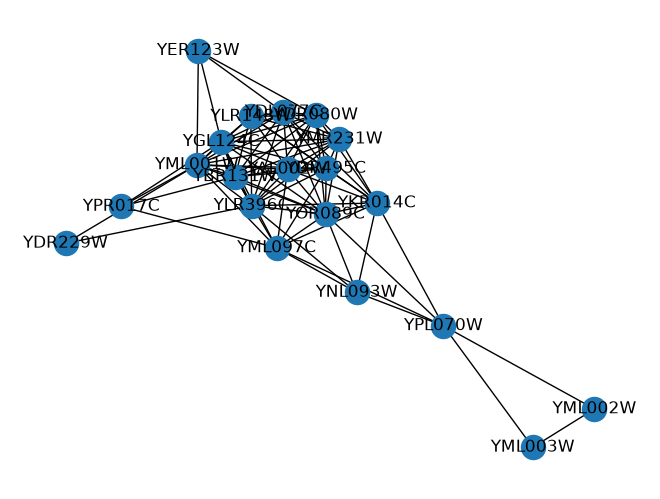

In [92]:
communities = eliminate_small_communities(G, threshold=3, seed=None, resolution=50)
sizes = np.array(size_distribution_of_communities(communities))

print(f"Average size of communitites: {np.mean(sizes)}")
print(f"Meduan size of communitites: {np.median(sizes)}")

plt.hist(sizes, bins=20)
plt.show()

target, adjacent = get_adjacent_communities(G, communities)
subG = G.subgraph(target)
nx.draw(subG, with_labels=True)
print(len(target))
print(max(sizes))

In [93]:
community_dict = {i: community for i, community in enumerate(communities, start=1)}
print(community_dict)

{1: {'YCR095W-A', 'YDR349C', 'YGR150C'}, 2: {'YCR010C', 'YAL054C', 'YKL217W'}, 3: {'YPR002W', 'YPR001W', 'YLR304C'}, 4: {'YOL114C', 'YBL057C', 'YHR189W'}, 5: {'YLR244C', 'YBL091C', 'YLR344W'}, 6: {'YBL099W', 'YJR077C', 'YMR056C'}, 7: {'YOR156C', 'YHR134W', 'YML032C'}, 8: {'YLR074C', 'YDL051W', 'YOR252W'}, 9: {'YDL181W', 'YDL130W-A', 'YBR039W'}, 10: {'YDR132C', 'YJL217W', 'YJL218W'}, 11: {'YKR064W', 'YDL191W', 'YDR520C'}, 12: {'YJR047C', 'YJR070C', 'YER156C'}, 13: {'YKL107W', 'YGL039W', 'YDR274C'}, 14: {'YGL101W', 'YNL058C', 'YJL136C'}, 15: {'YOR091W', 'YCR059C', 'YDR152W'}, 16: {'YHR089C', 'YHR052W', 'YBR034C'}, 17: {'YNL116W', 'YHR115C', 'YIL125W'}, 18: {'YKR094C', 'YJR161C', 'YJL151C'}, 19: {'YPL199C', 'YKL047W', 'YPL236C'}, 20: {'YOR381W-A', 'YMR320W', 'YOR385W'}, 21: {'YAL018C', 'YBL043W', 'YBL010C', 'YAL067C'}, 22: {'YNR021W', 'YJR153W', 'YJL189W', 'YDR051C'}, 23: {'YKL155C', 'YDR316W', 'YHR075C', 'YLR204W'}, 24: {'YPR191W', 'YGL226W', 'YDL189W', 'YBL045C'}, 25: {'YPL159C', 'YMR08

# weights
   1. normalised degree between communities

other methods might be used later.

This might be a good thing to look into.

In [94]:
def weights(G, communities) -> dict[tuple[int, int], float]:
    """
    Given a graph and its communitites, compute the weights of edges within this community.

    Parameters
    ---------
    G : nx.Graph
        The complete graph
    communities : list[set()]
        List of our communities. Each list contains a set of nodes corresponding to a community

    Returns
    --------
    normalised_weights : dict[tuple[int, int] : float]
        The weights for our edges. Each edge (i, j) is given a weight. Weights are computed as the
        number of edges between community i and j, divided by the number of nodes in community i 
        multiplied by its density plus the number of nodes in community j multiplied by its density.

    Notes
    -----
    The actual method for finding weights is something we should have a play around with.
    """
    sizes = np.array(size_distribution_of_communities(communities))
    n = len(communities)
    
    # precompute node -> community index lookup
    node_to_comm = {}
    for i, c in enumerate(communities):
        for node in c:
            node_to_comm[node] = i
    
    # precompute density per community
    densities = np.zeros(n)
    for i, c in enumerate(communities):
        subG = G.subgraph(c)
        densities[i] = nx.density(subG)
    
    edge_weights = {}
    
    for u, v in G.edges():
        ci, cj = node_to_comm[u], node_to_comm[v]
        if ci == cj:
            continue  # skip internal edges, only care about inter-community
        
        pair = tuple(sorted((ci, cj)))
        edge_weights[pair] = edge_weights.get(pair, 0) + 1
    
    # normalize each pair's raw connection count by density and size of both communities
    normalised_weights = {}
    for (i, j), count in edge_weights.items():
        denom = (densities[i] * sizes[i]) + (densities[j] * sizes[j])
        normalised_weights[(i, j)] = count / denom if denom > 0 else 0
    
    return normalised_weights

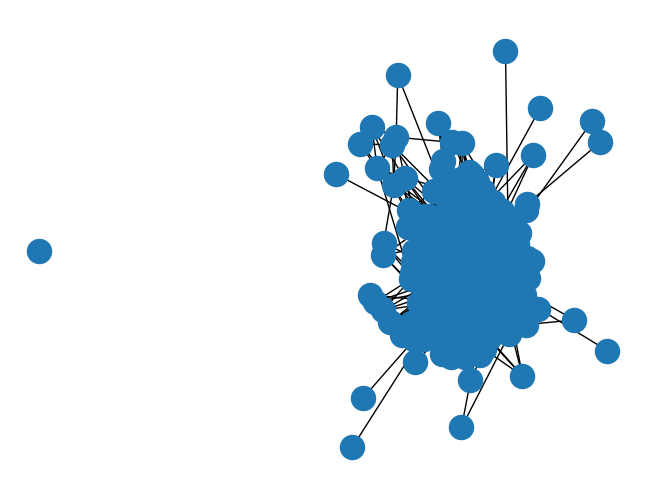

In [95]:
subgraph_nodes = []
for c in communities:
    for n in c:
        if n not in subgraph_nodes:
            subgraph_nodes.append(n)

G = nx.subgraph(G=G, nbunch=subgraph_nodes)
w = weights(G, communities)  # dict like {(i, j): weight, ...}

G_reduced = nx.Graph()
G_reduced.add_nodes_from(community_dict.keys())

for (i, j), weight in w.items():
    G_reduced.add_edge(i, j, weight=weight)

nx.draw(G_reduced)

In [96]:
print(len(G_reduced))

285


For evaluating our methods.
1. Pearson correlation
2. comparing centrality measures
3. Need to know what we want to preserve

In [97]:
from src.centrality_measures import all_node_centrality_measures

In [98]:
reduced_metrics = all_node_centrality_measures(
    G_reduced
)

df = pd.DataFrame(reduced_metrics).transpose()
df.index.name = "protein"
df.head()

# df.to_csv("data/processed/reduced_graph_centrality_measures.csv")

,degree,eigenvector,katz,page rank,betweenness,subgraph,closeness
protein,,,,,,,
1,21.0,0.077733,0.059237,0.003264,0.000762,0.006047,0.420274
2,28.0,0.093401,0.059278,0.005817,0.002851,0.008731,0.437894
3,7.0,0.006455,0.059154,0.001841,0.000217,0.000042,0.360158
4,33.0,0.040981,0.059308,0.004908,0.010104,0.001681,0.451929
5,29.0,0.074914,0.059284,0.004221,0.003941,0.005615,0.451929


In [99]:
metrics = pd.read_csv("data/processed/centrality_measures.csv")
reduced_metrics = pd.read_csv("data/processed/reduced_graph_centrality_measures.csv")
reduced_metrics.head()

,protein,degree,eigenvector,katz,page rank,betweenness,subgraph,closeness
0,1,29.0,0.073284,0.058173,0.004595,0.005054,1.030145e+10,0.448328
1,2,12.0,0.022163,0.058074,0.001969,0.000884,9.429637e+08,0.401361
2,3,14.0,0.047910,0.058086,0.003699,0.000408,4.402993e+09,0.403005
3,4,14.0,0.015390,0.058086,0.003518,0.004540,4.542282e+08,0.400815
4,5,3.0,0.003998,0.058022,0.000886,0.000030,3.064411e+07,0.339471


In [100]:
reduced_metrics.head()

,protein,degree,eigenvector,katz,page rank,betweenness,subgraph,closeness
0,1,29.0,0.073284,0.058173,0.004595,0.005054,1.030145e+10,0.448328
1,2,12.0,0.022163,0.058074,0.001969,0.000884,9.429637e+08,0.401361
2,3,14.0,0.047910,0.058086,0.003699,0.000408,4.402993e+09,0.403005
3,4,14.0,0.015390,0.058086,0.003518,0.004540,4.542282e+08,0.400815
4,5,3.0,0.003998,0.058022,0.000886,0.000030,3.064411e+07,0.339471


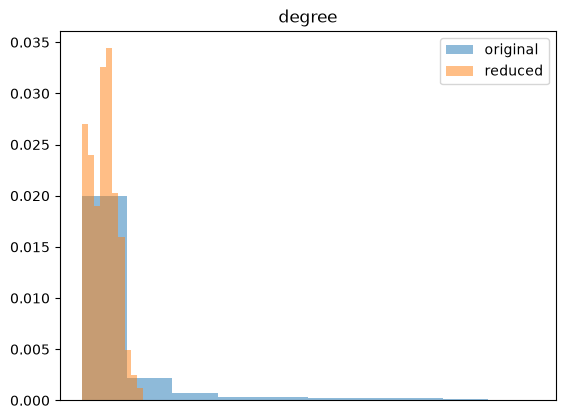

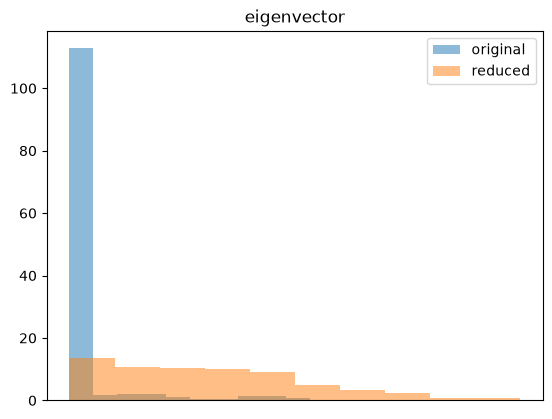

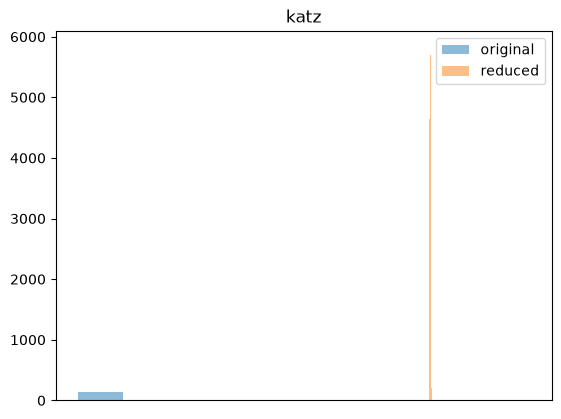

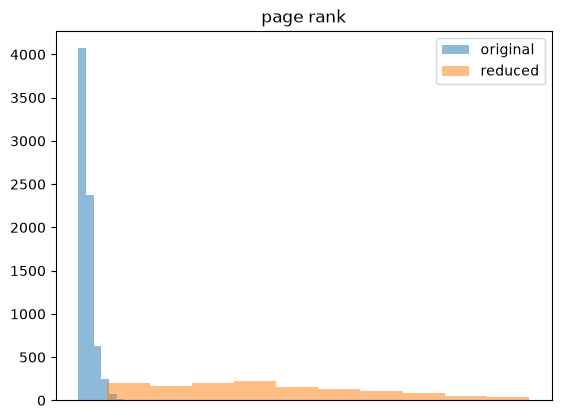

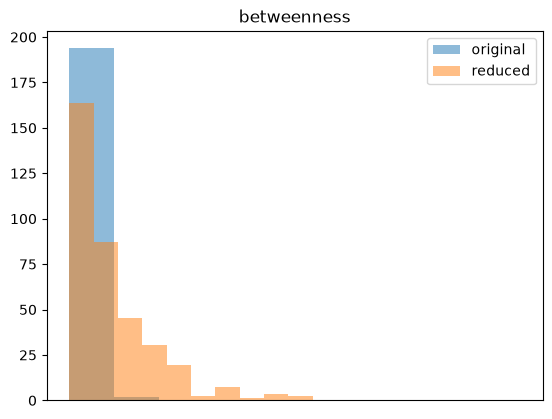

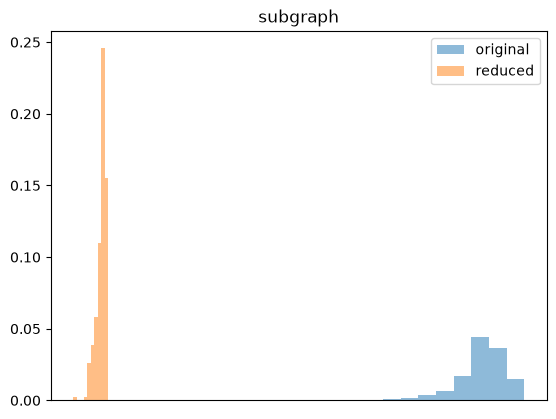

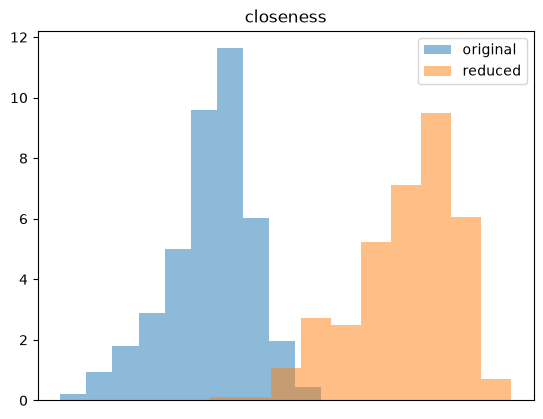

In [101]:
bins = np.linspace(0, 100, 30)
alpha = 0.5

for metric in metrics.columns:

    if metric=='protein':
        continue

    if metric=='subgraph':
        metrics[metric] = np.log(metrics[metric])
        reduced_metrics[metric] = np.log(reduced_metrics[metric])

    fig, ax = plt.subplots()
    
    ax.hist(metrics[metric], density=True, alpha=alpha,label="original")
    ax.hist(reduced_metrics[metric], density=True, alpha=alpha, label="reduced")
    
    ax.set_title(metric)
    ax.set_xticks([])
    plt.legend()
    
    plt.show()

In [102]:
print(metrics['subgraph'])
print(reduced_metrics['subgraph'])

0       186.426975
1       186.426975
2       186.426975
3       186.426975
4       186.426975
           ...    
5516    165.707022
5517    154.950545
5518    162.745971
5519    162.745971
5520    162.745971
Name: subgraph, Length: 5521, dtype: float64
0      23.055550
1      20.664538
2      22.205550
3      19.934110
4      17.237951
         ...    
291    22.021411
292    16.552137
293    22.962040
294    17.782558
295    23.238550
Name: subgraph, Length: 296, dtype: float64


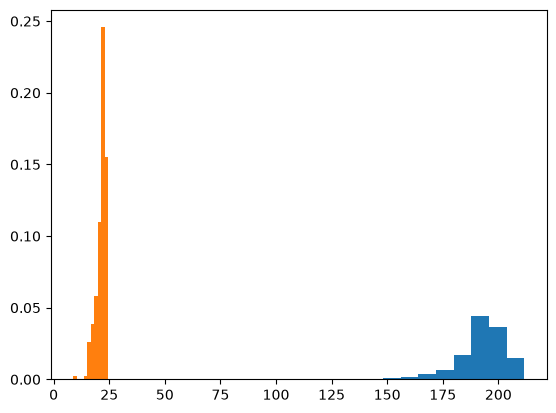

In [103]:
plt.hist(metrics['subgraph'], density=True)
plt.hist(reduced_metrics['subgraph'], density=True)
plt.show()